# Lecture 6 — Class Exercise
## Part-to-Whole: Hierarchical Visualization

> **Push to:** `week06/lecture06_exercise.ipynb`

**Rules:**
1. Use `px` first, then customise with `update_traces` / `update_layout`
2. Colour encodes a meaningful category — not decoration
3. Insight title names the specific finding
4. Consider: would a bar chart be clearer? If yes, use the bar chart

---


In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('../data/global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


## Task 1 — Treemap: fossil fuel dependency by country

**What to build:** A treemap showing **fossil fuel TWh only**, broken down by Region → Country → Source (Coal / Oil / Natural Gas).

**Requirements:**
- Filter to fossil sources only before plotting
- Use `path=['Region', 'Country', 'Source']` for the hierarchy
- Colour encodes the fossil source type (Coal / Oil / Natural Gas) with a CVD-safe palette
- Show TWh values in labels — no percentages
- Grey out parent nodes (Region and Country level)
- Insight title naming which region or country is most fossil-dependent

> 💡 `df.loc[df['Source_Type'] == 'Fossil']`


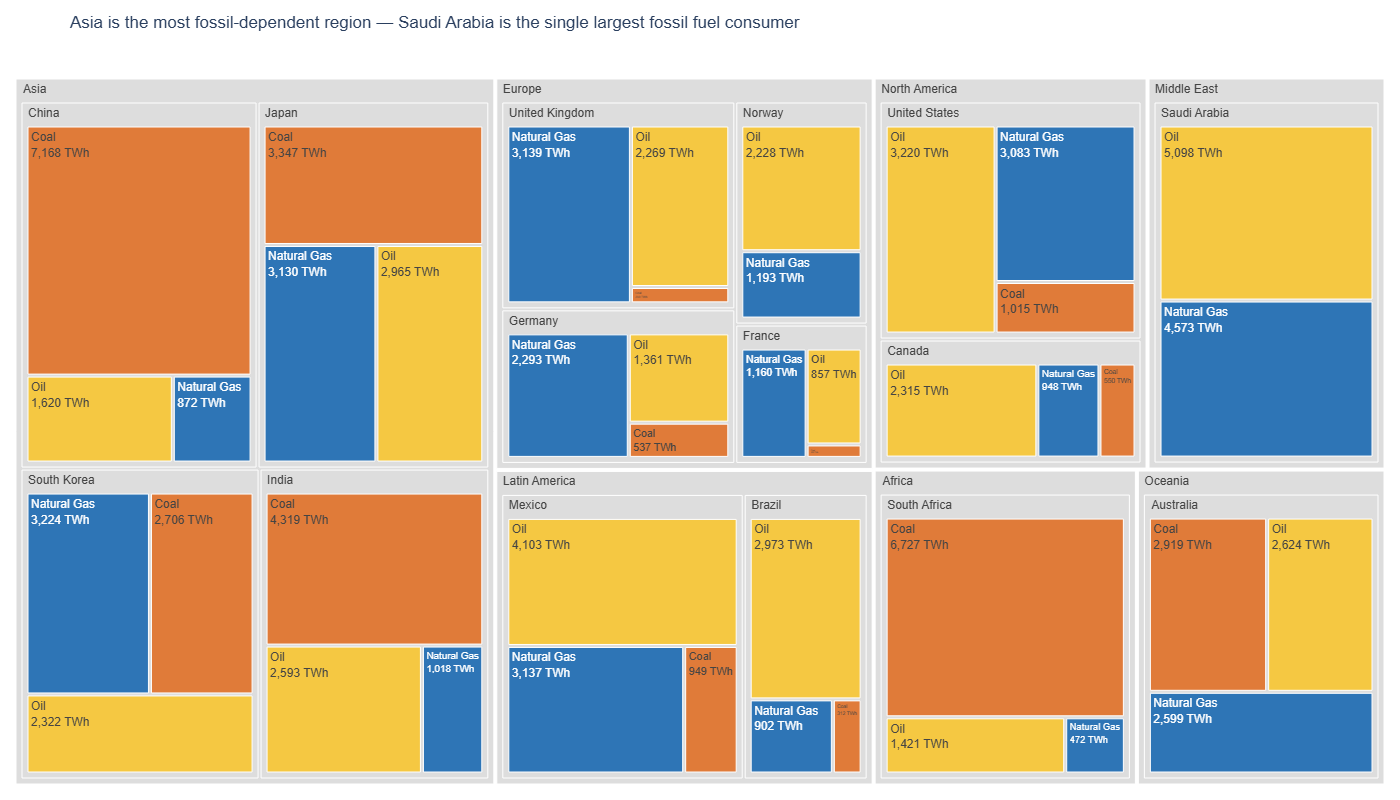

In [22]:
# Task 1
import plotly.io as pio
pio.renderers.default = "png"

# Filter to fossil sources only
df_fossil = df.loc[df['Source_Type'] == 'Fossil']

# CVD-safe colour palette for the three fossil sources
fossil_color_map = {
    'Coal':        '#E07B39',   # orange
    'Oil':         '#F5C842',   # yellow
    'Natural Gas': '#2E75B6',   # blue
}

# Step 1: Plotly Express base chart
fig = px.treemap(
    df_fossil,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map=fossil_color_map,
    labels={'TWh': 'Energy (TWh)', 'Source': 'Fossil Source'},
    height=800, width=1400
)

# Step 2: Customisation — show label + TWh, no percentages
fig.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>'
)

# Grey out parent nodes (Region and Country level)
fig.data[0].marker.colors = [
    c if c in fossil_color_map.values() else '#DDDDDD'
    for c in fig.data[0].marker.colors
]

fig.update_layout(
    title='Asia is the most fossil-dependent region — Saudi Arabia is the single largest fossil fuel consumer',
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=55, b=10),
    paper_bgcolor='white',
)

fig.show()


## Task 2 — Sunburst: tipping behaviour by day and meal time

**What to build:** A sunburst chart using the built-in `tips` dataset showing how **total bill amount** is distributed across day → time → smoker status.

**Requirements:**
- Load tips with `px.data.tips()`
- Aggregate **total bill** (sum of `total_bill`) per group — not count
- Hierarchy: `path=['day', 'time', 'smoker']`
- Colour encodes smoker status with a CVD-safe blue/orange palette
- Grey out parent nodes (day and time level)
- Use `percent parent` for text labels
- Insight title describing where the most spending happens

> 💡 `tips.groupby(['day', 'time', 'smoker'])['total_bill'].sum().reset_index()`


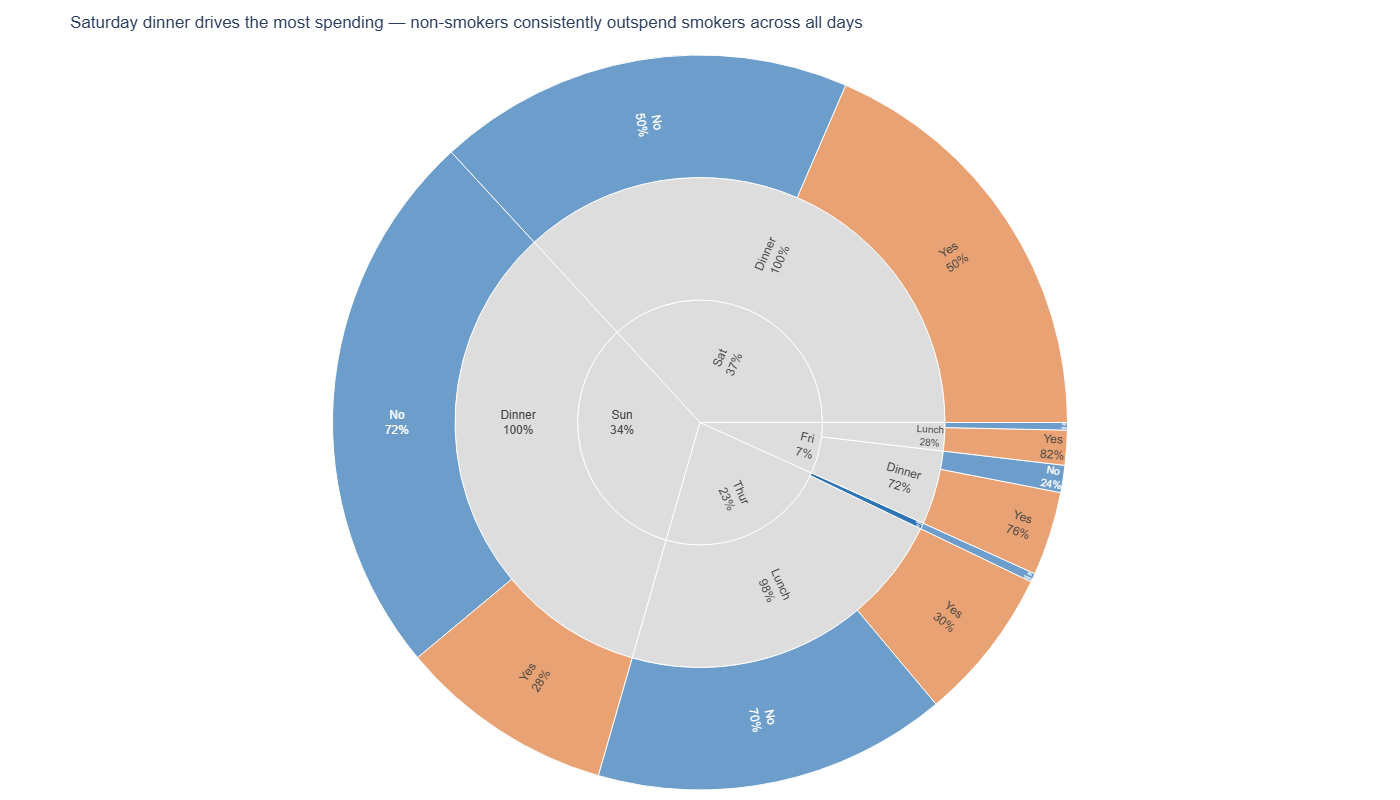

In [21]:
# Task 2
import plotly.io as pio
pio.renderers.default = "png"

# Load tips dataset
tips = px.data.tips()

# Aggregate total bill (sum) per group — not count
df_sun = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

# CVD-safe blue/orange palette for smoker status
smoker_color_map = {
    'No':  '#2E75B6',   # blue: non-smoker
    'Yes': '#E07B39',   # orange: smoker
}

# Step 1: Plotly Express base chart
fig = px.sunburst(
    df_sun,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map=smoker_color_map,
    labels={'total_bill': 'Total Bill ($)', 'smoker': 'Smoker'},
    width=1400, 
    height=800
)

# Step 2: Customisation — percent parent for text labels
fig.update_traces(
    textinfo='label+percent parent',
    hovertemplate='<b>%{label}</b><br>Total Bill: $%{value:,.2f}<br>%{percentParent:.0%} of %{parent}<extra></extra>',
    insidetextorientation='radial',
)

# Grey out parent nodes (day and time level)
fig.data[0].marker.colors = [
    c if c in smoker_color_map.values() else '#DDDDDD'
    for c in fig.data[0].marker.colors
]

fig.update_layout(
    title='Saturday dinner drives the most spending — non-smokers consistently outspend smokers across all days',
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=55, b=10),
    paper_bgcolor='white',
)

fig.show()


## Task 3 — Treemap vs bar: low-carbon energy by country

**What to build:** Build **both** a treemap and a horizontal bar chart showing total low-carbon TWh (Nuclear + Hydro) per country. Then answer the question in a markdown cell below.

**Requirements:**
- Filter to `Source_Type == 'Low-carbon'` and aggregate TWh by country
- Treemap: single-level `path=['All', 'Country']` with a dummy root node labelled `'Low-carbon'`
- Bar chart: sorted by TWh, horizontal orientation, CVD-safe colour
- Both charts show TWh values, not percentages
- Insight title on the bar chart naming the leading country


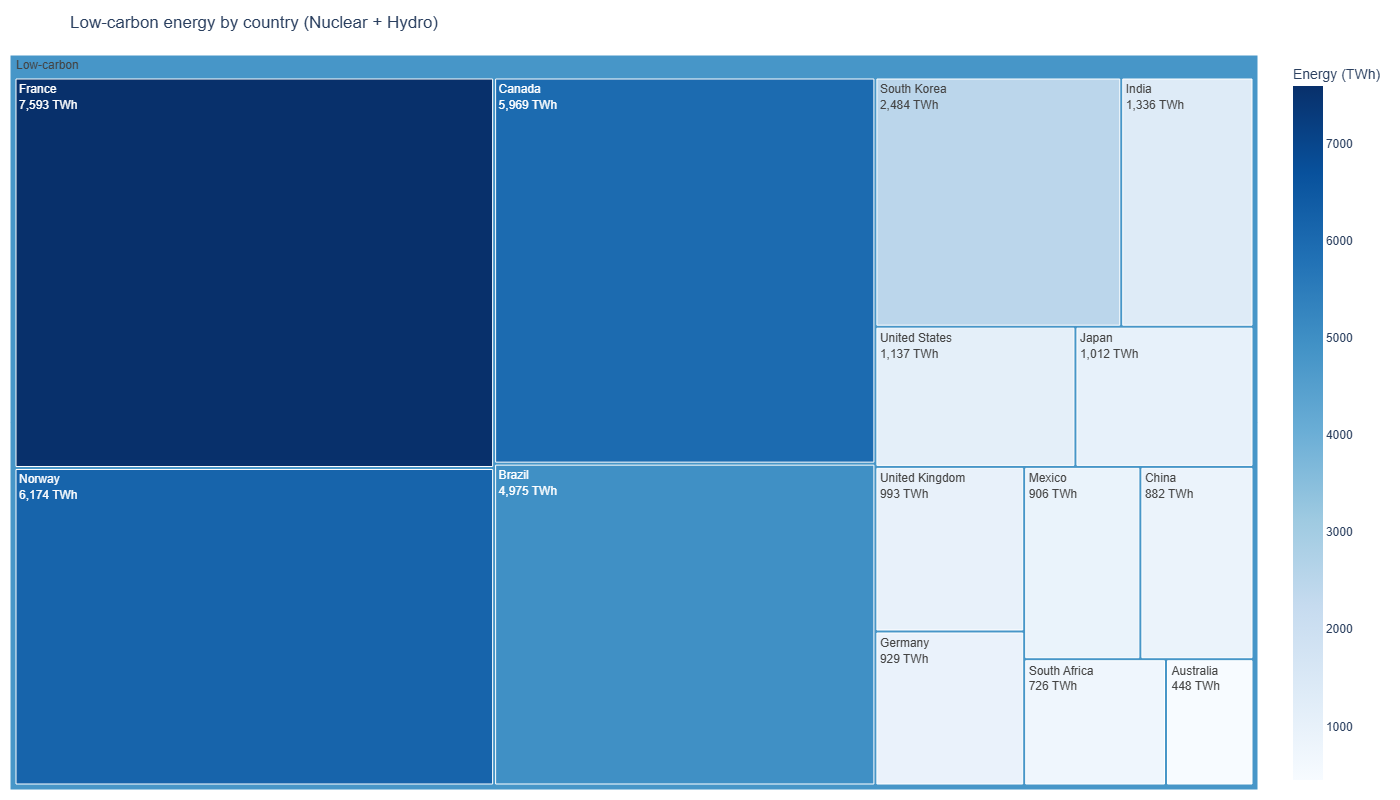

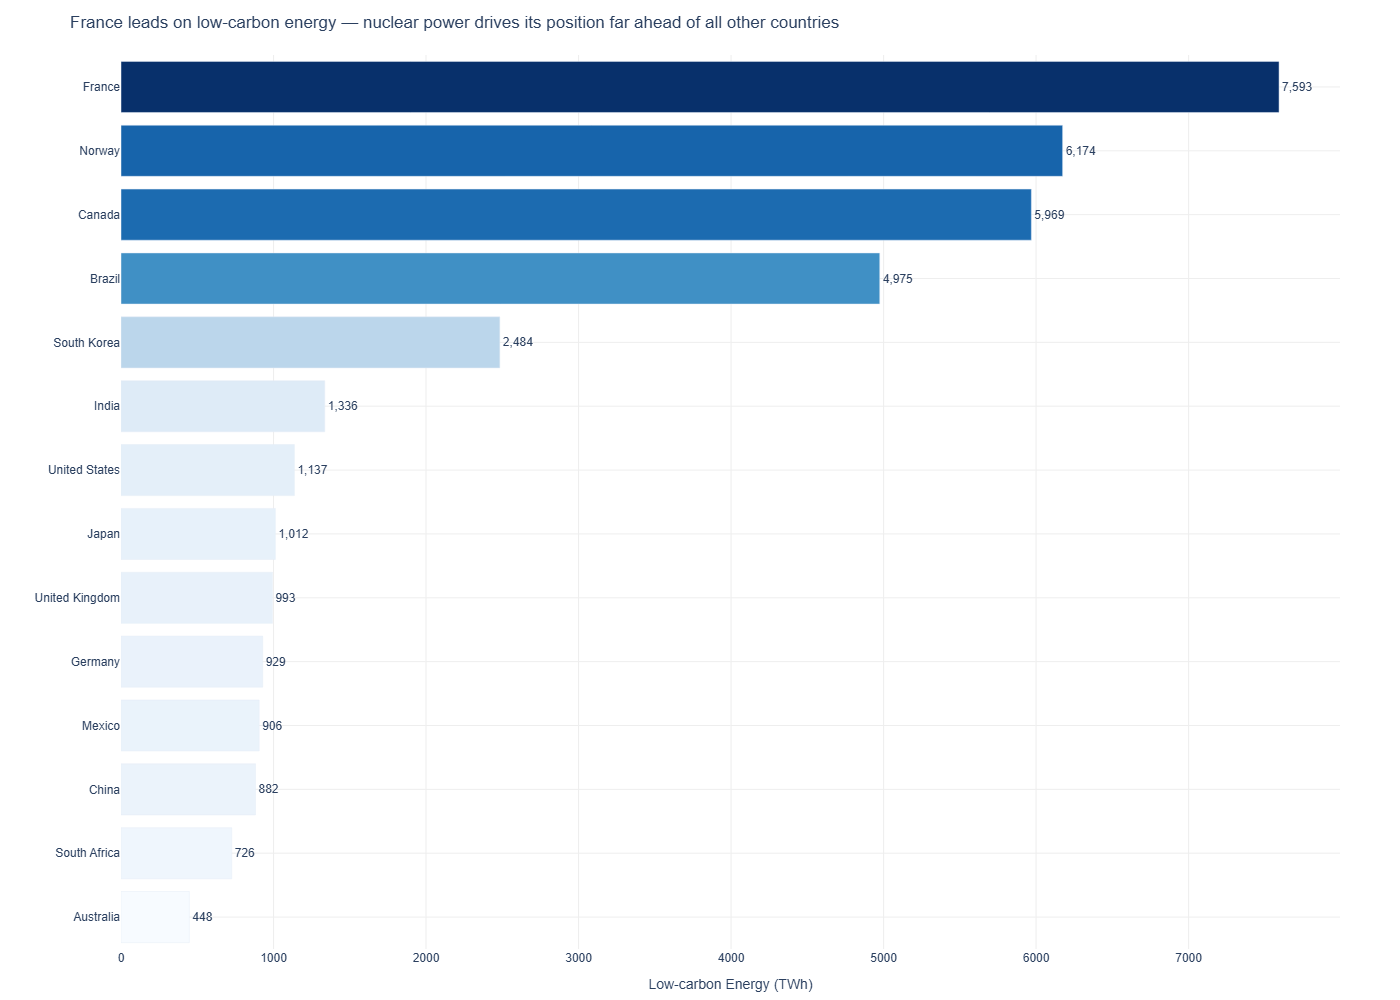

In [19]:
# Task 3 — charts
import plotly.io as pio
pio.renderers.default = "png"

# Filter to low-carbon and aggregate TWh by country
low_carbon = (
    df.loc[df['Source_Type'] == 'Low-carbon']
    .groupby('Country')['TWh']
    .sum()
    .reset_index()
)
low_carbon = low_carbon.sort_values('TWh')

# Dummy root node labelled 'Low-carbon'
low_carbon['All'] = 'Low-carbon'

# ── Treemap ────────────────────────────────────────────────────────────────────
fig_tree = px.treemap(
    low_carbon,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    labels={'TWh': 'Energy (TWh)'},
    title='Low-carbon energy by country (Nuclear + Hydro)',
    width=1400, 
    height=800
)
fig_tree.update_traces(
    textinfo='label',
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    hovertemplate='<b>%{label}</b><br>%{value:,.0f} TWh<extra></extra>',
    root_color='white',
)
fig_tree.update_layout(
    font=dict(family='Arial', size=12),
    margin=dict(l=10, r=10, t=55, b=10),
    paper_bgcolor='white',
)
fig_tree.show()

# ── Bar chart (sorted, horizontal, CVD-safe colour) ───────────────────────────
fig_bar = px.bar(
    low_carbon,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    labels={'TWh': 'Low-carbon Energy (TWh)', 'Country': ''},
    title='France leads on low-carbon energy — nuclear power drives its position far ahead of all other countries',
    height=1000, width=1400
)
fig_bar.update_traces(
    texttemplate='%{x:,.0f}',
    textposition='outside',
)
fig_bar.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    coloraxis_showscale=False,
    margin=dict(l=10, r=60, t=55, b=10),
)
fig_bar.update_xaxes(gridcolor='#EEEEEE')
fig_bar.update_yaxes(gridcolor='#EEEEEE')
fig_bar.show()
